In [6]:
#캘리포니아 주택
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

data = fetch_california_housing()

X = data.data
y = data.target

x_train_full,x_test,y_train_full,y_test = train_test_split(X, y, test_size = 0.2, random_state=42) 
x_train,x_valid,y_train,y_valid = train_test_split(x_train_full, y_train_full, test_size=0.25, random_state=42)

x_train.shape, x_valid.shape, x_test.shape

((12384, 8), (4128, 8), (4128, 8))

In [ ]:
# 훈련데이터로 가중치 학습
# 미니배치 경사하강법 + 역전파
# 손실을 줄이도록 파라미터를 반복 업데이트

In [14]:
import tensorflow as tf

tf.random.set_seed(42)
normal_layer = tf.keras.layers.Normalization(input_shape=(8,))
model = tf.keras.Sequential([
    normal_layer,
    tf.keras.layers.Dense(50, activation='relu'),
    tf.keras.layers.Dense(50, activation='relu'),
    tf.keras.layers.Dense(50, activation='relu'),
    tf.keras.layers.Dense(1)
])
model.compile(loss='mse', optimizer='adam', metrics=['RootMeanSquaredError'])
normal_layer.adapt(x_train)
history = model.fit(x_train, y_train, epochs=20, validation_data=(x_valid,y_valid) )


Epoch 1/20
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - RootMeanSquaredError: 0.9440 - loss: 0.8911 - val_RootMeanSquaredError: 0.6562 - val_loss: 0.4306
Epoch 2/20
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - RootMeanSquaredError: 0.6293 - loss: 0.3961 - val_RootMeanSquaredError: 0.6201 - val_loss: 0.3845
Epoch 3/20
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - RootMeanSquaredError: 0.6021 - loss: 0.3625 - val_RootMeanSquaredError: 0.5952 - val_loss: 0.3542
Epoch 4/20
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - RootMeanSquaredError: 0.5851 - loss: 0.3423 - val_RootMeanSquaredError: 0.5828 - val_loss: 0.3396
Epoch 5/20
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - RootMeanSquaredError: 0.5736 - loss: 0.3291 - val_RootMeanSquaredError: 0.5738 - val_loss: 0.3292
Epoch 6/20
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - RootMeanSquaredError: 0.5660 - loss: 0.3203 - val_RootMeanSquaredError: 0.5800 - val_loss: 0.3364
Epoch 7/20
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - RootMeanSquaredError: 0.5618 - los

In [15]:
# 성능 측정
model.evaluate(x_test, y_test)

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 935us/step - RootMeanSquaredError: 0.5271 - loss: 0.2778


[0.27778494358062744, 0.5270530581474304]

In [16]:
history.history.keys()

dict_keys(['RootMeanSquaredError', 'loss', 'val_RootMeanSquaredError', 'val_loss'])

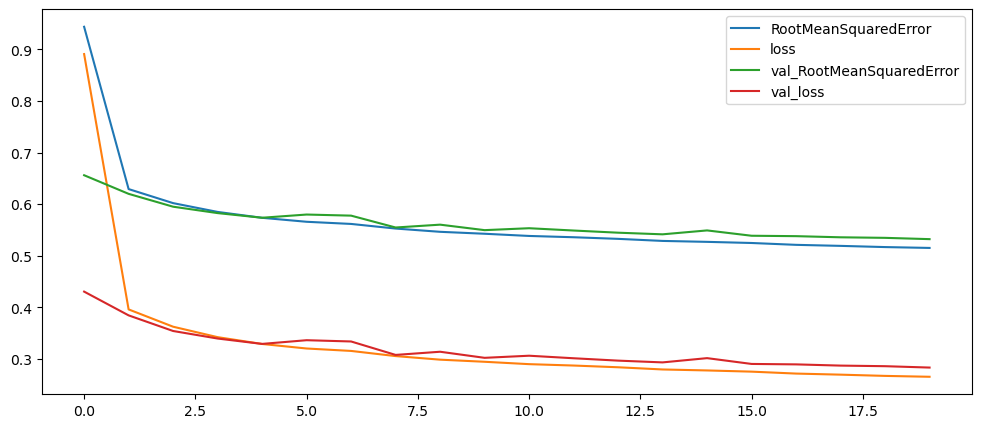

In [17]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(12, 5))
plt.plot(range(20), history.history['RootMeanSquaredError'], label = 'RootMeanSquaredError')
plt.plot(range(20), history.history['loss'], label='loss' )
plt.plot(range(20), history.history['val_RootMeanSquaredError'], label='val_RootMeanSquaredError')
plt.plot(range(20), history.history['val_loss'], label='val_loss' )
plt.legend()
plt.show()

In [18]:
from sklearn.metrics import r2_score
y_predict = model.predict(x_test)
r2_score(y_test, y_predict)

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 682us/step


0.7880166846126481

In [20]:
from sklearn.ensemble import RandomForestRegressor
sk_model = RandomForestRegressor(random_state=42)
sk_model.fit(x_train, y_train)
sk_y_predict = sk_model.predict(x_test)
r2_score(y_test, sk_y_predict)


0.8020423256887657

In [ ]:
# 함수형 API를 사용한 복잡한 모델 구축
# 와이드 & 딥 신경망 : 입력의 전부 또는 일부를 출력 레이어에 직접 연결
# 선형관계와 비선형 표현을 동시에 학습해 편향/분산 의 균형을 맞춤
# 저차원과 고차원 정보를 합쳐서 정보 손실을 줄임 

In [27]:
import tensorflow as tf
tf.keras.backend.clear_session() # 이전에 학습한 기록 지워줌
tf.random.set_seed(42)
input = tf.keras.layers.Input(shape=x_train.shape[1:])
normalization_layer = tf.keras.layers.Normalization()
hidden_layer1 = tf.keras.layers.Dense(50, activation='relu')
hidden_layer2 = tf.keras.layers.Dense(50, activation='relu')
hidden_layer3 = tf.keras.layers.Dense(50, activation='relu')
output_layer = tf.keras.layers.Dense(1)
concat_layer = tf.keras.layers.Concatenate()

normalized = normalization_layer(input)
hidden1 = hidden_layer1(normalized)
hidden2 = hidden_layer2(hidden1)
hidden3 = hidden_layer3(hidden2)
concat = concat_layer([normalized, hidden3])
output = output_layer(concat)

model = tf.keras.Model(inputs=[input], outputs=[output])
model.summary() # 파라미터 개수 확인 => 데이터 수에 비해 과도하면 과적합 위험


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 8)         │         17 │ input_layer[0][0] │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 50)        │        450 │ normalization[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 50)        │      2,550 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 50)        │      2,550 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 58)        │          0 │ normalization[0]… │
│ (Concatenate)       │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         59 │ concatenate[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,626 (21.98 KB)

 Trainable params: 5,609 (21.91 KB)

 Non-trainable params: 17 (72.00 B)

In [28]:
model.compile(loss='mse', optimizer='adam', metrics=['RootMeanSquaredError'])
normal_layer.adapt(x_train)
history = model.fit(x_train, y_train, epochs=20, validation_data=(x_valid,y_valid) )

Epoch 1/20
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - RootMeanSquaredError: 7.7412 - loss: 59.9262 - val_RootMeanSquaredError: 3.4801 - val_loss: 12.1108
Epoch 2/20
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - RootMeanSquaredError: 3.1263 - loss: 9.7735 - val_RootMeanSquaredError: 1.1908 - val_loss: 1.4180
Epoch 3/20
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - RootMeanSquaredError: 2.0060 - loss: 4.0242 - val_RootMeanSquaredError: 7.0017 - val_loss: 49.0236
Epoch 4/20
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - RootMeanSquaredError: 2.7745 - loss: 7.6977 - val_RootMeanSquaredError: 4.5210 - val_loss: 20.4392
Epoch 5/20
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - RootMeanSquaredError: 2.0263 - loss: 4.1060 - val_RootMeanSquaredError: 5.9091 - val_loss: 34.9178
Epoch 6/20
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - RootMeanSquaredError: 2.1231 - loss: 4.5075 - val_RootMeanSquaredError: 4.9189 - val_loss: 24.1960
Epoch 7/20
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - RootMeanSquaredError: 2.6536

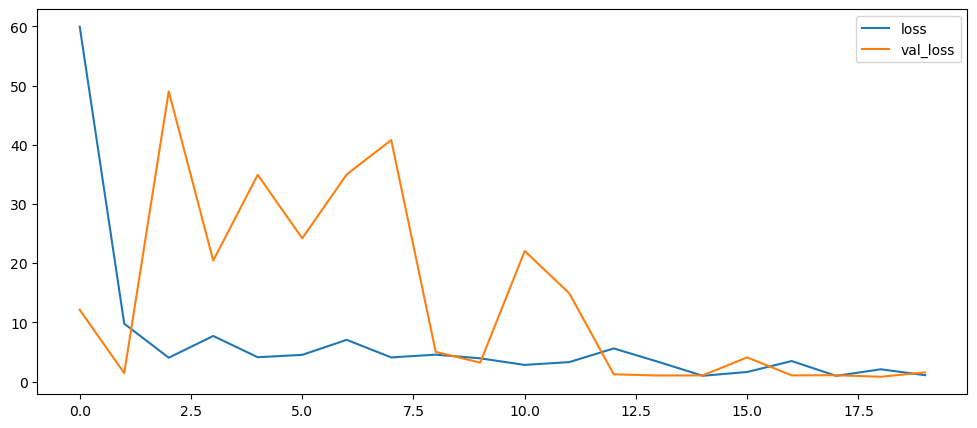

In [30]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(12, 5))
# plt.plot(range(20), history.history['RootMeanSquaredError'], label = 'RootMeanSquaredError')
plt.plot(range(20), history.history['loss'], label='loss' )
# plt.plot(range(20), history.history['val_RootMeanSquaredError'], label='val_RootMeanSquaredError')
plt.plot(range(20), history.history['val_loss'], label='val_loss' )
plt.legend()
plt.show()

In [31]:
from sklearn.metrics import r2_score
y_predict = model.predict(x_test)
r2_score(y_test, y_predict)

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 796us/step


-0.13157604998485994

In [45]:
x_train_wide, x_train_deep = x_train[:, :5], x_train[:, 2:]
x_valid_wide, x_valid_deep = x_valid[:, :5], x_valid[:, 2:]
x_test_wide, x_test_deep = x_test[:, :5], x_test[:, 2:]

# 다중경로
input_wide = tf.keras.layers.Input(shape=[5]) # 0 ~ 4 까지 특성
input_deep = tf.keras.layers.Input(shape=[6]) # 2 ~ 7
norm_layer_wide = tf.keras.layers.Normalization()
norm_layer_deep = tf.keras.layers.Normalization()
norm_wide = norm_layer_wide(input_wide)
norm_deep = norm_layer_deep(input_deep)

hidden1 = tf.keras.layers.Dense(30, activation='relu')(norm_deep)
hidden2 = tf.keras.layers.Dense(30, activation='relu')(hidden1)

concat = tf.keras.layers.concatenate([norm_wide, hidden2])
output = tf.keras.layers.Dense(1)(concat)

aux_output = tf.keras.layers.Dense(1)(hidden2)

model = tf.keras.Model(inputs = [input_wide, input_deep], outputs = [output, aux_output])

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
model.compile( loss = ('mse', 'mse'), loss_weights= (0.9, 0.1), optimizer=optimizer,
              metrics=['RootMeanSquaredError', 'RootMeanSquaredError'] )

norm_layer_wide.adapt(x_train_wide)
norm_layer_deep.adapt(x_train_deep)
history = model.fit(
    (x_train_wide, x_train_deep), (y_train, y_train), epochs=20, 
    validation_data=( (x_valid_wide, x_valid_deep), (y_valid, y_valid))
)

Epoch 1/20
387/387 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - dense_34_RootMeanSquaredError: 1.5258 - dense_34_loss: 2.3282 - dense_35_RootMeanSquaredError: 1.6182 - dense_35_loss: 2.6184 - loss: 2.3572 - val_dense_34_RootMeanSquaredError: 1.1550 - val_dense_34_loss: 1.3341 - val_dense_35_RootMeanSquaredError: 1.3267 - val_dense_35_loss: 1.7601 - val_loss: 1.3767
Epoch 2/20
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - dense_34_RootMeanSquaredError: 0.8433 - dense_34_loss: 0.7111 - dense_35_RootMeanSquaredError: 0.9097 - dense_35_loss: 0.8276 - loss: 0.7228 - val_dense_34_RootMeanSquaredError: 0.7658 - val_dense_34_loss: 0.5865 - val_dense_35_RootMeanSquaredError: 0.8169 - val_dense_35_loss: 0.6673 - val_loss: 0.5946
Epoch 3/20
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - dense_34_RootMeanSquaredError: 0.7213 - dense_34_loss: 0.5202 - dense_35_RootMeanSquaredError: 0.7760 - dense_35_loss: 0.6021 - loss: 0.5284 - val_dense_34_RootMeanSquaredError: 0.7083 - val_dense_34_loss: 0.5016 - val_dense_35_Ro

In [46]:
model.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_18      │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_18    │ (None, 6)         │         13 │ input_layer_18[0… │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_17      │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_32 (Dense)    │ (None, 30)        │        210 │ normalization_18… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_17    │ (None, 5)         │         11 │ input_layer_17[0… │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_33 (Dense)    │ (None, 30)        │        930 │ dense_32[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_8       │ (None, 35)        │          0 │ normalization_17… │
│ (Concatenate)       │                   │            │ dense_33[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_34 (Dense)    │ (None, 1)         │         36 │ concatenate_8[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_35 (Dense)    │ (None, 1)         │         31 │ dense_33[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,647 (14.26 KB)

 Trainable params: 1,207 (4.71 KB)

 Non-trainable params: 24 (104.00 B)

 Optimizer params: 2,416 (9.44 KB)

In [47]:
model.evaluate( (x_test_wide, x_test_deep), (y_test, y_test) )

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 959us/step - dense_34_RootMeanSquaredError: 0.5797 - dense_34_loss: 0.3360 - dense_35_RootMeanSquaredError: 0.6343 - dense_35_loss: 0.4023 - loss: 0.3427


[0.3426620066165924,
 0.33603787422180176,
 0.4022789001464844,
 0.5796877145767212,
 0.6342545747756958]

In [48]:
model.predict( (x_test_wide, x_test_deep) )

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 727us/step


[array([[0.42639923],
        [1.2254627 ],
        [3.5839028 ],
        ...,
        [4.6923013 ],
        [0.88027775],
        [1.7711785 ]], shape=(4128, 1), dtype=float32),
 array([[0.45202214],
        [1.0006781 ],
        [3.3428183 ],
        ...,
        [4.5665708 ],
        [0.9735856 ],
        [1.605366  ]], shape=(4128, 1), dtype=float32)]

In [44]:
y_test

array([0.477  , 0.458  , 5.00001, ..., 5.00001, 0.723  , 1.515  ],
      shape=(4128,))

In [50]:
import torch.nn as nn
import torch

$$
MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2
$$

In [54]:
# 예측값과 정답값(회귀)
pred = torch.tensor([2.5, 5.0, 7.5])
target = torch.tensor([3.0, 5.0, 7.0])

# pytorch에서 제공하는 MSELoss 함수
mse_buildin = nn.MSELoss()(pred, target)
mse_buildin 

# 수식 기반 수작업
mse_manual = torch.mean( (pred - target) ** 2 )
print(f"mse_buildin: {mse_buildin}")
print(f"mse_manual: {mse_manual}")

mse_buildin: 0.1666666716337204
mse_manual: 0.1666666716337204


$$
BCE = -\frac{1}{n}\sum_{i=1}^{n}\left[y_i\log(\hat{y}_i)+(1-y_i)\log(1-\hat{y}_i)\right]
$$

In [53]:
# 단일 샘플 y = 1일 때 식은 -log(y_hat) 단순화되고.. 그래서 정답 확률이 높을수록 손실이 낮아지는 형태가 된다.
y = torch.tensor( [1.0] ) 
y_hat_good = torch.tensor( [0.9] ) # 정답 확률 높음
y_hat_bad = torch.tensor( [0.1] ) # 정답 확률 낮음
# 수작업 계산
bce_good_manual = -( y * torch.log(y_hat_good) + (1-y) * torch.log(1-y_hat_good) )
bce_bad_manual = -( y * torch.log(y_hat_bad) + (1-y) * torch.log(1 - y_hat_bad) )

# 내장된 BCE
bce_good_builtin = nn.BCELoss()( y_hat_good, y )
bce_bad_builtin = nn.BCELoss()( y_hat_bad, y )
print( f"bce_good_manual: {bce_good_manual}" )
print( f"bce_bad_manual: {bce_bad_manual}" )
print( f"bce_good_builtin: {bce_good_builtin}" )
print( f"bce_bad_builtin: {bce_bad_builtin}" )

bce_good_manual: tensor([0.1054])
bce_bad_manual: tensor([2.3026])
bce_good_builtin: 0.10536054521799088
bce_bad_builtin: 2.3025851249694824


In [ ]:
# BCE 배치 계산
prob_pred = torch.tensor( [0.9, 0.2, 0.4] )
label = torch.tensor( [1.0, 0.0, 1.0] )

loss = -torch.mean(
    label * torch.log(prob_pred) + (1 - label) * torch.log(1 - prob_pred)
)
print(loss)

nn.BCELoss()(prob_pred, label)

tensor(0.4149)


tensor(0.4149)

$$
CE = -\sum_{i=1}^{m} y_i\log(\hat{y}_i)
$$


In [75]:
# CE 다중분류 손실
# 클래스 3개 [고양이, 강아지, 토끼], 정답이 강아지 (index=1)
target_index = torch.tensor([1])
one_hot = torch.tensor([[0.0, 1.0, 0.0]]) # 원-핫 인코딩 된 정답

# 좋은 예측과 나쁜 예측
p_good = torch.tensor([0.2, 0.7, 0.1])
p_bad = torch.tensor([0.7, 0.2, 0.1])

# 수작업
ce_good_manual = -( one_hot * torch.log(p_good) ).sum() 
ce_bad_manual = -( one_hot * torch.log(p_bad) ).sum() 

# # torch ce, logits 입력 log(p)
ce_loss = nn.CrossEntropyLoss()
ce_good_builtin = ce_loss( torch.log(p_good).unsqueeze(0), target_index )
ce_bad_builtin = ce_loss( torch.log(p_bad).unsqueeze(0), target_index )

print(ce_good_manual, ce_good_builtin)
print(ce_bad_manual, ce_bad_builtin)

tensor(0.3567) tensor(0.3567)
tensor(1.6094) tensor(1.6094)


In [93]:
from sklearn.datasets import load_diabetes # 회귀
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
X, y = load_diabetes(return_X_y=True)

x_train,x_test,y_train,y_test = train_test_split(X, y, random_state=42)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

x_train_t = torch.tensor(x_train, dtype=torch.float32)
x_test_t = torch.tensor(x_test, dtype=torch.float32)
x_train_t.shape, y_train.shape
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_test_t = torch.tensor(y_test,dtype=torch.float32).unsqueeze(1)

reg_model = nn.Sequential(
    nn.Linear(x_train_t.shape[1], 64),
    nn.ReLU(),
    nn.Linear(64, 1)
)

mse_loss = nn.MSELoss()
optimizer = torch.optim.Adam(reg_model.parameters(), lr=1e-2)
epochs = 300
for _ in range(epochs):
    optimizer.zero_grad() # 이전 가중치 초기화
    pred = reg_model(x_train_t)
    loss = mse_loss(pred, y_train_t)
    loss.backward() # 가중치 찾아서 각 계산과정에 배치
    optimizer.step() # 각 계산 과정의 가중치와 바이어스를 업데이트
    
with torch.no_grad():
    test_pred = reg_model(x_test_t)
    test_mse = mse_loss(test_pred, y_test_t)

# test_mse 텐서에 들어 있음, 출력이나 기타 산술연산이 필요함, 꺼네기 위해 item()

print(f"test mse : {test_mse.item():.4f}")

from sklearn.metrics import r2_score
r2_score(y_test_t, test_pred)


test mse : 3055.6060


0.447418212890625

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score
# 1. 딥러닝 레이어 sequential에서 입력을 받는 부분을 수정, feature 개수
# 2. 출력 레이어의 활성화 함수로 시그모이드
# 3. 손실 함수로 nn.BCELoss()
# 4. 추론 with .... 0.5 보다 크면 1 그렇지 않으면 0
X, y = load_breast_cancer(return_X_y=True)

x_train,x_test,y_train,y_test = train_test_split(X, y, random_state=42)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

x_train_t = torch.tensor(x_train, dtype=torch.float32)
x_test_t = torch.tensor(x_test, dtype=torch.float32)
x_train_t.shape, y_train.shape
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_test_t = torch.tensor(y_test,dtype=torch.float32).unsqueeze(1)

clf_model = nn.Sequential(
    nn.Linear(x_train_t.shape[1], 64),
    nn.ReLU(),
    nn.Linear(64, 1),
    nn.Sigmoid()
)

bce_loss = nn.BCELoss()
optimizer = torch.optim.Adam(clf_model.parameters(), lr=1e-2)
epochs = 300
for _ in range(epochs):
    optimizer.zero_grad() # 이전 가중치 초기화
    pred = clf_model(x_train_t)
    loss = bce_loss(pred, y_train_t)
    loss.backward() # 가중치 찾아서 각 계산과정에 배치
    optimizer.step() # 각 계산 과정의 가중치와 바이어스를 업데이트
    
with torch.no_grad():
    test_pred_proba = clf_model(x_test_t)
    test_pred_class = (test_pred_proba > 0.5).float()
    test_bce = bce_loss(test_pred_proba, y_test_t)

print(f"test bce loss : {test_bce.item():.4f}")

acc = accuracy_score(y_test_t, test_pred_class)
print(f"accuracy      : {acc:.4f}")



test bce loss : 0.1758
accuracy      : 0.9650


In [131]:
# CE
# 신경망의 입력데이터 개수
# 신경망의 최종 출력의 뉴런 수 3
# 손실함수 nn.CrossEntropyLoss()
from sklearn.datasets import load_iris
from sklearn.metrics import classification_report
X, y = load_iris(return_X_y=True)

x_train,x_test,y_train,y_test = train_test_split(X, y, random_state=42)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

x_train_t = torch.tensor(x_train, dtype=torch.float32)
x_test_t = torch.tensor(x_test, dtype=torch.float32)
x_train_t.shape, y_train.shape
y_train_t = torch.tensor(y_train, dtype=torch.long)
y_test_t = torch.tensor(y_test,dtype=torch.long)

clf_model = nn.Sequential(
    nn.Linear(x_train_t.shape[1], 64),
    nn.ReLU(),
    nn.Linear(64, 3),
    nn.Softmax()
)

ce_loss = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(clf_model.parameters(), lr=1e-2)
epochs = 300
for _ in range(epochs):
    optimizer.zero_grad() # 이전 가중치 초기화
    logits = clf_model(x_train_t)
    loss = ce_loss(logits, y_train_t)
    loss.backward() # 가중치 찾아서 각 계산과정에 배치
    optimizer.step() # 각 계산 과정의 가중치와 바이어스를 업데이트
    

with torch.no_grad():
    test_pred = clf_model(x_test_t)
    test_ce = ce_loss(test_pred, y_test_t)

(torch.argmax(test_pred, dim=1) == y_test)




c:\Users\Playdata\miniconda3\Lib\site-packages\torch\nn\modules\module.py:1779: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


tensor([ True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True, False,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True])